In [37]:
import numpy as np
import pandas as pd
from scipy.linalg import hankel
import matplotlib.pyplot as plt

In [38]:
df = pd.read_hdf('Data/TemporalNoise1f_v2.h5', key='data')
frame_rate = 60
window_size = 600/1000
bin_size = 1/frame_rate
nsims = 20
print(df['cell_type'].unique())
cell_type ='OFF transient alpha'
# cell_type = 'OFF sustained alpha'
# cell_type = 'ON alpha'
cell_name     = '061225Bc5'
ctype_df = df[df['cell_type'] == cell_type]
cell_text = True
save = True
print('#'*60)
print('Processing cell type:', cell_type)

['OFF transient alpha' 'ON alpha' 'ON delayed' 'OFF sustained alpha']
############################################################
Processing cell type: OFF transient alpha


In [39]:
data = ctype_df.query('cell_name == @cell_name and beta == 0.0').reset_index(drop=True)
print('Processing cell:', cell_name)

stim_nr    = np.stack(data.loc[data.noise_seed != 1, 'stimulus'])
stim_rs    = np.stack(data.loc[data.noise_seed == 1, 'stimulus'])
spk_nr     = np.stack(data.loc[data.noise_seed != 1, 'spike_train'])
spk_rs     = np.stack(data.loc[data.noise_seed == 1, 'spike_train'])
test_psth  = spk_rs.mean(axis=0) / bin_size

n_trials, n_frames = stim_nr.shape
ntfilt     = int(window_size / bin_size)


Processing cell: 061225Bc5


In [40]:
# pre-compute Hankelised stimulus for every trial once
hankel_list = []
for tr in range(n_trials):
    pad        = np.hstack([np.zeros(ntfilt-1), stim_nr[tr].ravel()])
    design_tr  = hankel(pad[:-ntfilt+1], stim_nr[tr, -ntfilt:])
    hankel_list.append(design_tr)          # (frames, ntfilt)

design_trn = np.vstack(hankel_list)
spk_trn    = spk_nr.ravel()


In [41]:
def _difference_matrix(n: int, order: int = 2) -> np.ndarray:
    """
    Return a finite-difference matrix of given order.
    For order = 1:  D  @ k  ≈  Δk
    For order = 2:  D² @ k  ≈  Δ²k   (curvature / roughness)
    """
    D = np.eye(n)
    for _ in range(order):
        D = np.diff(D, n=1, axis=0)
    return D


In [42]:
def whitened_reverse_correlation_smooth(S, r, eps=0.95, alpha=1e-3,
                                        lambda_smooth=1e-2, diff_order=2):
    n, m = S.shape
    Sc = S - S.mean(axis=0, keepdims=True)
    C = (Sc.T @ Sc) / n
    eigvals, V = np.linalg.eigh(C)
    idx = np.argsort(eigvals)[::-1]
    eigvals, V = eigvals[idx], V[:, idx]
    var_exp = eigvals / eigvals.sum()
    cum_var = np.cumsum(var_exp)

    k_count = int(np.searchsorted(cum_var, float(eps), side="left") + 1)
    k_count = max(1, min(k_count, m))

    B = V[:, :k_count]                  # (m, k)
    k = B.shape[1]                      # <- single source of truth

    S_pca = Sc @ B                      # (n, k)
    ridge  = alpha * np.eye(k)          # (k, k)

    D  = _difference_matrix(m, order=diff_order)   # (m-d, m)
    Dp = D @ B                                      # (m-d, k)
    smooth = lambda_smooth * (Dp.T @ Dp)            # (k, k)

    # sanity checks (helpful during debugging)
    assert S_pca.shape[1] == k and ridge.shape == (k,k) and smooth.shape == (k,k)

    M   = S_pca.T @ S_pca + ridge + smooth         # (k, k)
    rhs = S_pca.T @ r                               # (k,)
    w   = np.linalg.solve(M, rhs)
    k_est = B @ w
    return k_est, k, var_exp, cum_var

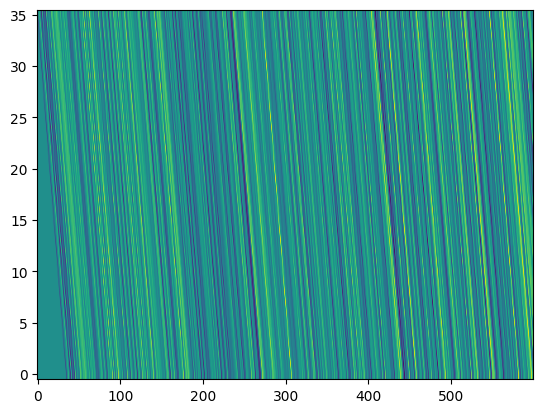

In [43]:
plt.imshow(hankel_list[1].T, aspect='auto', origin='lower')

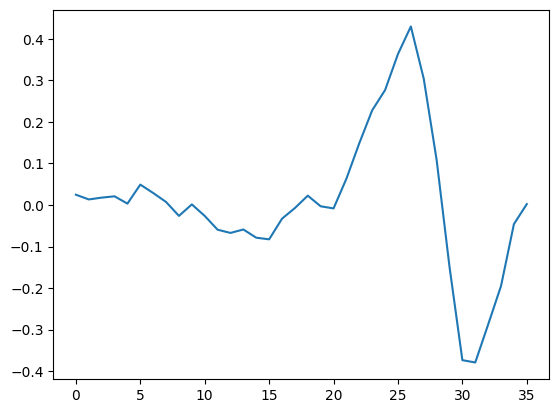

In [45]:
eps = 1.0, 
rf_est, _, _, _ = whitened_reverse_correlation_smooth(
                    design_trn, spk_trn,)

plt.plot(rf_est)